# Intelligent Vehicle Damage Assessment Using Deep Learning

## Model Comparison: YOLO11m vs YOLOv8m vs Faster R-CNN vs RT-DETR

This notebook trains and compares four state-of-the-art object detection models on the CarDD dataset for vehicle damage detection.

### Damage Categories
1. Dent
2. Scratch
3. Crack
4. Glass Shatter
5. Lamp Broken
6. Tire Flat

---

## 1. Setup and Configuration

In [2]:
# Install required packages (uncomment if needed)
!pip install torch torchvision ultralytics clearml pycocotools albumentations opencv-python matplotlib seaborn pandas pyyaml tqdm tabulate

  Using cached clearml-2.1.5-py2.py3-none-any.whl.metadata (18 kB)
  Using cached pycocotools-2.0.11-cp312-abi3-win_amd64.whl.metadata (1.3 kB)
  Using cached albumentations-2.0.8-py3-none-any.whl.metadata (43 kB)
  Using cached tabulate-0.10.0-py3-none-any.whl.metadata (40 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached furl-2.1.4-py2.py3-none-any.whl.metadata (25 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached pathlib2-2.3.7.post1-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached pyjwt-2.12.1-py3-none-any.whl.metadata (4.1 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached rpds_py-0.30.0-cp313-cp313-win_amd64.whl.metadata (4.2 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached albucore-0.0.24-py3-none-any.whl.metadata (5.3 kB)
  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached stringzill

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\Bush\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



In [1]:
!nvidia-smi

Tue Apr  7 17:10:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5070 Ti   WDDM  |   00000000:02:00.0  On |                  N/A |
| 30%   43C    P0             74W /  300W |    6279MiB /  16303MiB |     20%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip uninstall torch torchvision torchaudio -y

In [3]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu130

Looking in indexes: https://download.pytorch.org/whl/cu130
   ---------------------------------------- 0.0/1.9 GB ? eta -:--:--
   ---------------------------------------- 0.0/1.9 GB 4.3 MB/s eta 0:07:31
   ---------------------------------------- 0.0/1.9 GB 4.6 MB/s eta 0:07:01
   ---------------------------------------- 0.0/1.9 GB 4.4 MB/s eta 0:07:12
   ---------------------------------------- 0.0/1.9 GB 4.5 MB/s eta 0:07:06
   ---------------------------------------- 0.0/1.9 GB 3.7 MB/s eta 0:08:35
   ---------------------------------------- 0.0/1.9 GB 3.0 MB/s eta 0:10:41
   ---------------------------------------- 0.0/1.9 GB 3.0 MB/s eta 0:10:41
   ---------------------------------------- 0.0/1.9 GB 2.5 MB/s eta 0:12:37
   ---------------------------------------- 0.0/1.9 GB 2.5 MB/s eta 0:12:37
   ---------------------------------------- 0.0/1.9 GB 2.2 MB/s eta 0:14:26
   ---------------------------------------- 0.0/1.9 GB 2.2 MB/s eta 0:14:30
   ---------------------------------

In [4]:
import os
import sys
import json
import yaml
import time
import shutil
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
# from tqdm.notebook import tqdm
from tqdm.auto import tqdm
from tabulate import tabulate

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from ultralytics import YOLO, RTDETR

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

PyTorch version: 2.11.0+cu130
Torchvision version: 0.26.0+cu130


### 1.1 Device Configuration (CUDA / MPS / CPU)

In [5]:
def get_device():
    """
    Automatically detect and return the best available device.
    Priority: CUDA (NVIDIA GPU) > MPS (Apple Silicon) > CPU
    """
    if torch.cuda.is_available():
        device = torch.device("cuda")
        device_name = torch.cuda.get_device_name(0)
        device_count = torch.cuda.device_count()
        memory = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"✓ Using CUDA: {device_name}")
        print(f"  - Available GPUs: {device_count}")
        print(f"  - GPU Memory: {memory:.2f} GB")
        return device, "cuda"
    
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = torch.device("mps")
        print("✓ Using MPS (Apple Silicon GPU)")
        # Check if MPS is actually built
        if torch.backends.mps.is_built():
            print("  - MPS backend is properly built")
        return device, "mps"
    
    else:
        device = torch.device("cpu")
        print("✓ Using CPU")
        print(f"  - CPU cores: {os.cpu_count()}")
        return device, "cpu"

DEVICE, DEVICE_TYPE = get_device()
print(f"\nSelected device: {DEVICE}")

✓ Using CUDA: NVIDIA GeForce RTX 5070 Ti
  - Available GPUs: 1
  - GPU Memory: 17.09 GB

Selected device: cuda


### 1.2 ClearML Integration

In [6]:
!pip install clearml

In [ ]:
import os
from clearml import Task

# Configure ClearML endpoints (override via environment if needed)
os.environ['CLEARML_API_HOST'] = os.getenv('CLEARML_API_HOST', 'https://api.clear.ml')
os.environ['CLEARML_WEB_HOST'] = os.getenv('CLEARML_WEB_HOST', 'https://app.clear.ml')
os.environ['CLEARML_FILES_HOST'] = os.getenv('CLEARML_FILES_HOST', 'https://files.clear.ml')

# Require credentials from environment to avoid hardcoding secrets in notebooks
required_clearml_vars = ['CLEARML_API_ACCESS_KEY', 'CLEARML_API_SECRET_KEY']
missing_clearml_vars = [k for k in required_clearml_vars if not os.getenv(k)]
if missing_clearml_vars:
    raise EnvironmentError(
        'Missing ClearML credentials in environment: '
        + ', '.join(missing_clearml_vars)
        + '. Set them before running this cell.'
    )

# Initialize ClearML Task
task = Task.init(
    project_name='Vehicle-Damage-Assessment',
    task_name=f"Model-Comparison-{datetime.now().strftime('%Y%m%d_%H%M%S')}",
    task_type=Task.TaskTypes.training,
    auto_connect_frameworks=True,
)

# Get ClearML logger
clearml_logger = task.get_logger()

print('✓ ClearML Task initialized')
print(f'  Task ID: {task.id}')
print('  Project: Vehicle-Damage-Assessment')

ClearML Task: created new task id=155e4084a37c43029cbcc07d4b259d67
2026-04-07 17:20:45,115 - clearml.Task - INFO - No repository found, storing script code instead
ClearML results page: https://app.clear.ml/projects/5f374d74aadd4f9b9d496f62636e87b2/experiments/155e4084a37c43029cbcc07d4b259d67/output/log
✓ ClearML Task initialized
  Task ID: 155e4084a37c43029cbcc07d4b259d67
  Project: Vehicle-Damage-Assessment


2026-04-07 17:21:44,224 - clearml.storage - INFO - Uploading: 12.80MB from C:/Users/Bush/AppData/Local/Temp/tmpmpv7to36.png


                                            0% | 0.00/12.8 MB [00:00<?, ?MB/s]: 

2026-04-07 17:21:44,274 - clearml.storage - INFO - Uploading: 12.80MB from C:/Users/Bush/AppData/Local/Temp/tmpfmcgymn0.png


████████████████████████████████ 100% | 12.80/12.8 MB [00:43<00:00,  3.36s/MB]: 
████████████████████████████████ 100% | 12.80/12.8 MB [00:43<00:00,  3.36s/MB]: 


ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start
ClearML Monitor: Reporting detected, reverting back to iteration based reporting


### 1.3 Configuration

In [19]:
# Configuration
CONFIG = {
    # Dataset paths
    'DATA_ROOT': '../data/CarDD/CarDD_COCO',
    'TRAIN_IMAGES': 'train2017',
    'VAL_IMAGES': 'val2017',
    'TEST_IMAGES': 'test2017',
    'TRAIN_ANN': 'annotations/instances_train2017.json',
    'VAL_ANN': 'annotations/instances_val2017.json',
    'TEST_ANN': 'annotations/instances_test2017.json',

    # Existing YOLO dataset location
    'YOLO_DATA_DIR': '../data/CarDD/CarDD_YOLO',

    # Model output
    'OUTPUT_DIR': '../models',
    'EXPERIMENT_NAME': f"exp_{datetime.now().strftime('%Y%m%d_%H%M%S')}",

    # Training parameters
    'EPOCHS': 100,
    'BATCH_SIZE': 16 if DEVICE_TYPE == 'cuda' else 8,
    'IMAGE_SIZE': 640,
    'LEARNING_RATE': 0.001,
    'WEIGHT_DECAY': 0.0005,
    'NUM_WORKERS': 8 if DEVICE_TYPE != 'mps' else 0,  # MPS doesn't support multiprocessing well

    # Evaluation
    'CONF_THRESHOLD': 0.25,
    'IOU_THRESHOLD': 0.45,

    # Classes
    'NUM_CLASSES': 6,
    'CLASS_NAMES': ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat'],
}

# Adjust batch size based on device
if DEVICE_TYPE == 'mps':
    CONFIG['BATCH_SIZE'] = 8  # Reduce for MPS stability
    CONFIG['NUM_WORKERS'] = 0  # MPS has issues with multiprocessing

# Log configuration to ClearML
task.connect(CONFIG)

# Create output directories
os.makedirs(CONFIG['OUTPUT_DIR'], exist_ok=True)
os.makedirs(CONFIG['YOLO_DATA_DIR'], exist_ok=True)

print('Configuration:')
for key, value in CONFIG.items():
    print(f'  {key}: {value}')

Configuration:
  DATA_ROOT: ../data/CarDD/CarDD_COCO
  TRAIN_IMAGES: train2017
  VAL_IMAGES: val2017
  TEST_IMAGES: test2017
  TRAIN_ANN: annotations/instances_train2017.json
  VAL_ANN: annotations/instances_val2017.json
  TEST_ANN: annotations/instances_test2017.json
  YOLO_DATA_DIR: ../data/CarDD/CarDD_YOLO
  OUTPUT_DIR: ../models
  EXPERIMENT_NAME: exp_20260407_184509
  EPOCHS: 100
  BATCH_SIZE: 16
  IMAGE_SIZE: 640
  LEARNING_RATE: 0.001
  WEIGHT_DECAY: 0.0005
  NUM_WORKERS: 8
  CONF_THRESHOLD: 0.25
  IOU_THRESHOLD: 0.45
  NUM_CLASSES: 6
  CLASS_NAMES: ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']


---
## 2. Dataset Exploration and Preparation

In [9]:
# Load COCO annotations
data_root = Path(CONFIG['DATA_ROOT'])

train_ann_path = data_root / CONFIG['TRAIN_ANN']
val_ann_path = data_root / CONFIG['VAL_ANN']
test_ann_path = data_root / CONFIG['TEST_ANN']

print("Loading annotations...")
train_coco = COCO(train_ann_path)
val_coco = COCO(val_ann_path)
test_coco = COCO(test_ann_path)

print(f"\nDataset Statistics:")
print(f"  Train: {len(train_coco.imgs)} images, {len(train_coco.anns)} annotations")
print(f"  Val:   {len(val_coco.imgs)} images, {len(val_coco.anns)} annotations")
print(f"  Test:  {len(test_coco.imgs)} images, {len(test_coco.anns)} annotations")

Loading annotations...
loading annotations into memory...
Done (t=0.10s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!

Dataset Statistics:
  Train: 2816 images, 6211 annotations
  Val:   810 images, 1744 annotations
  Test:  374 images, 785 annotations


In [10]:
# Display categories
categories = train_coco.loadCats(train_coco.getCatIds())
print("\nDamage Categories:")
for cat in categories:
    print(f"  ID {cat['id']}: {cat['name']}")


Damage Categories:
  ID 1: dent
  ID 2: scratch
  ID 3: crack
  ID 4: glass shatter
  ID 5: lamp broken
  ID 6: tire flat


In [11]:
# Analyze class distribution
def get_class_distribution(coco_obj):
    """Count annotations per class"""
    class_counts = defaultdict(int)
    for ann_id in coco_obj.anns:
        ann = coco_obj.anns[ann_id]
        cat_id = ann['category_id']
        cat_name = coco_obj.loadCats([cat_id])[0]['name']
        class_counts[cat_name] += 1
    return dict(class_counts)

train_dist = get_class_distribution(train_coco)
val_dist = get_class_distribution(val_coco)
test_dist = get_class_distribution(test_coco)

# Create distribution dataframe
dist_df = pd.DataFrame({
    'Class': CONFIG['CLASS_NAMES'],
    'Train': [train_dist.get(c, 0) for c in CONFIG['CLASS_NAMES']],
    'Val': [val_dist.get(c, 0) for c in CONFIG['CLASS_NAMES']],
    'Test': [test_dist.get(c, 0) for c in CONFIG['CLASS_NAMES']]
})
dist_df['Total'] = dist_df['Train'] + dist_df['Val'] + dist_df['Test']

print("\nClass Distribution:")
print(tabulate(dist_df, headers='keys', tablefmt='grid', showindex=False))

# Log to ClearML
clearml_logger.report_table("Class Distribution", "Dataset Split", table_plot=dist_df)


Class Distribution:
+---------------+---------+-------+--------+---------+
| Class         |   Train |   Val |   Test |   Total |
+===============+=========+=======+========+=========+
| dent          |    1806 |   501 |    236 |    2543 |
+---------------+---------+-------+--------+---------+
| scratch       |    2560 |   728 |    307 |    3595 |
+---------------+---------+-------+--------+---------+
| crack         |     651 |   177 |     70 |     898 |
+---------------+---------+-------+--------+---------+
| glass shatter |     475 |   135 |     71 |     681 |
+---------------+---------+-------+--------+---------+
| lamp broken   |     494 |   141 |     69 |     704 |
+---------------+---------+-------+--------+---------+
| tire flat     |     225 |    62 |     32 |     319 |
+---------------+---------+-------+--------+---------+


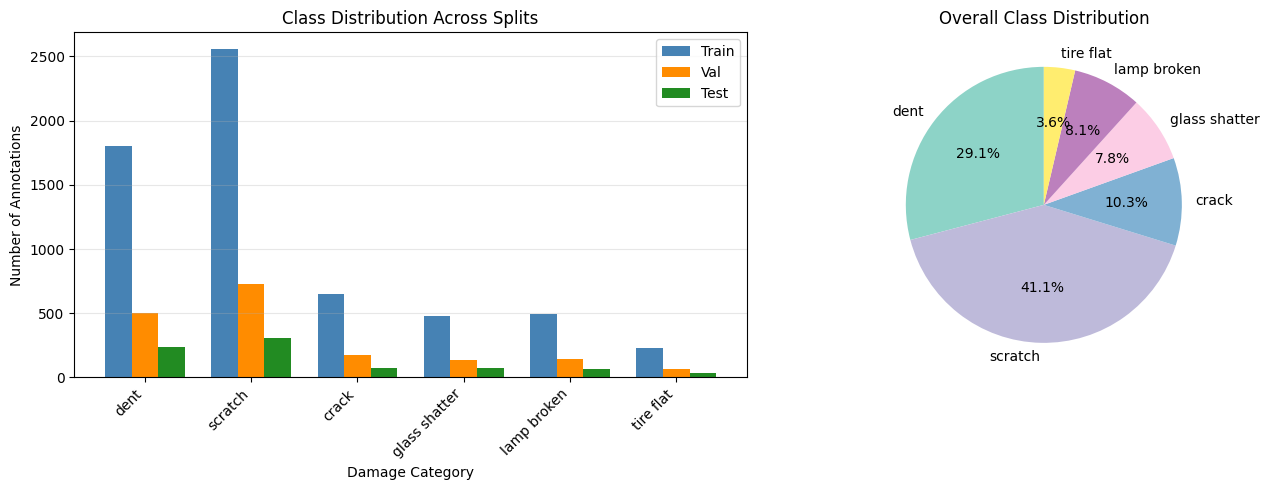

In [12]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
x = np.arange(len(CONFIG['CLASS_NAMES']))
width = 0.25

bars1 = axes[0].bar(x - width, dist_df['Train'], width, label='Train', color='steelblue')
bars2 = axes[0].bar(x, dist_df['Val'], width, label='Val', color='darkorange')
bars3 = axes[0].bar(x + width, dist_df['Test'], width, label='Test', color='forestgreen')

axes[0].set_xlabel('Damage Category')
axes[0].set_ylabel('Number of Annotations')
axes[0].set_title('Class Distribution Across Splits')
axes[0].set_xticks(x)
axes[0].set_xticklabels(CONFIG['CLASS_NAMES'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Pie chart for total distribution
colors = plt.cm.Set3(np.linspace(0, 1, len(CONFIG['CLASS_NAMES'])))
axes[1].pie(dist_df['Total'], labels=CONFIG['CLASS_NAMES'], autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Overall Class Distribution')

plt.tight_layout()
plt.savefig(f"{CONFIG['OUTPUT_DIR']}/class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# Log to ClearML
clearml_logger.report_matplotlib_figure("Dataset", "Class Distribution", fig)

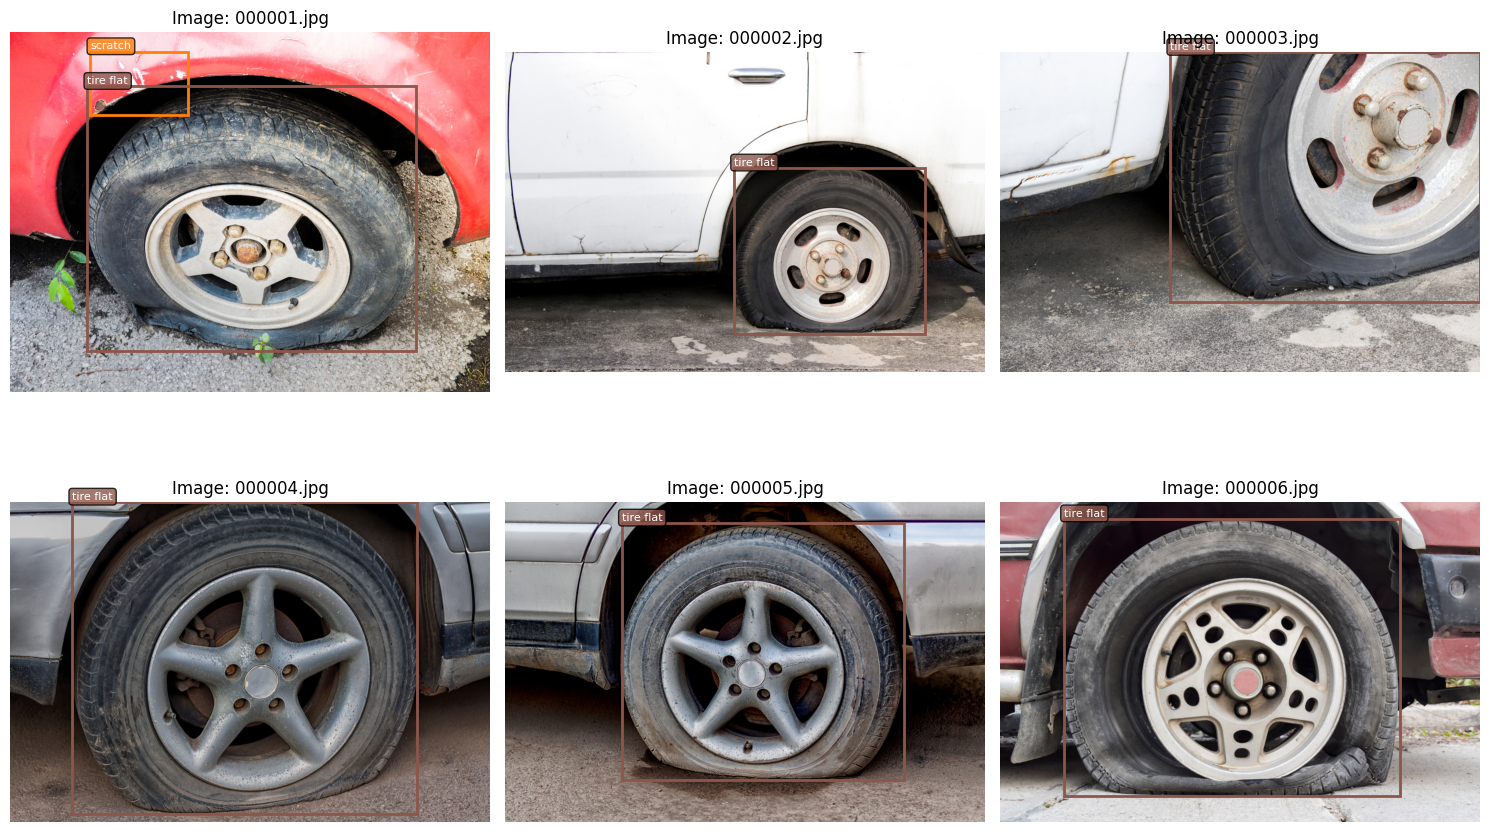

In [13]:
# Visualize sample images with annotations
def visualize_sample_images(coco_obj, img_dir, num_samples=6):
    """Display sample images with bounding boxes"""
    img_ids = list(coco_obj.imgs.keys())[:num_samples]
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    class_colors = {i+1: colors[i] for i in range(6)}
    
    for idx, img_id in enumerate(img_ids):
        img_info = coco_obj.loadImgs(img_id)[0]
        img_path = os.path.join(img_dir, img_info['file_name'])
        img = Image.open(img_path)
        
        axes[idx].imshow(img)
        
        # Get annotations for this image
        ann_ids = coco_obj.getAnnIds(imgIds=img_id)
        anns = coco_obj.loadAnns(ann_ids)
        
        for ann in anns:
            bbox = ann['bbox']  # [x, y, width, height]
            cat_id = ann['category_id']
            cat_name = coco_obj.loadCats([cat_id])[0]['name']
            color = class_colors.get(cat_id, colors[0])
            
            rect = plt.Rectangle(
                (bbox[0], bbox[1]), bbox[2], bbox[3],
                fill=False, edgecolor=color, linewidth=2
            )
            axes[idx].add_patch(rect)
            axes[idx].text(
                bbox[0], bbox[1] - 5, cat_name,
                color='white', fontsize=8,
                bbox=dict(boxstyle='round', facecolor=color, alpha=0.8)
            )
        
        axes[idx].set_title(f'Image: {img_info["file_name"]}')
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(f"{CONFIG['OUTPUT_DIR']}/sample_images.png", dpi=150, bbox_inches='tight')
    plt.show()
    return fig

train_img_dir = data_root / CONFIG['TRAIN_IMAGES']
fig = visualize_sample_images(train_coco, train_img_dir)
clearml_logger.report_matplotlib_figure("Dataset", "Sample Images", fig)

### 2.1 Prepare YOLO Format Dataset

In [20]:
def convert_coco_to_yolo(coco_obj, img_dir, output_dir, split_name):
    """
    Convert COCO format annotations to YOLO format.
    YOLO format: class_id center_x center_y width height (normalized)
    """
    img_output_dir = os.path.join(output_dir, 'images', split_name)
    label_output_dir = os.path.join(output_dir, 'labels', split_name)

    os.makedirs(img_output_dir, exist_ok=True)
    os.makedirs(label_output_dir, exist_ok=True)

    for img_id in tqdm(coco_obj.imgs, desc=f'Converting {split_name}'):
        img_info = coco_obj.loadImgs(img_id)[0]
        img_width = img_info['width']
        img_height = img_info['height']
        img_filename = img_info['file_name']

        # Copy image (or create symlink)
        src_img = os.path.join(img_dir, img_filename)
        dst_img = os.path.join(img_output_dir, img_filename)
        if not os.path.exists(dst_img):
            shutil.copy2(src_img, dst_img)

        # Get annotations
        ann_ids = coco_obj.getAnnIds(imgIds=img_id)
        anns = coco_obj.loadAnns(ann_ids)

        # Write YOLO format labels
        label_filename = os.path.splitext(img_filename)[0] + '.txt'
        label_path = os.path.join(label_output_dir, label_filename)

        with open(label_path, 'w') as f:
            for ann in anns:
                # COCO bbox: [x_min, y_min, width, height]
                bbox = ann['bbox']
                cat_id = ann['category_id'] - 1  # YOLO uses 0-indexed classes

                # Convert to YOLO format (center_x, center_y, width, height) normalized
                center_x = (bbox[0] + bbox[2] / 2) / img_width
                center_y = (bbox[1] + bbox[3] / 2) / img_height
                width = bbox[2] / img_width
                height = bbox[3] / img_height

                # Clamp values to [0, 1]
                center_x = max(0, min(1, center_x))
                center_y = max(0, min(1, center_y))
                width = max(0, min(1, width))
                height = max(0, min(1, height))

                f.write(f"{cat_id} {center_x:.6f} {center_y:.6f} {width:.6f} {height:.6f}\n")

    return img_output_dir, label_output_dir

# Use an existing YOLO dataset if available; otherwise convert from COCO
yolo_data_dir = os.path.abspath(CONFIG['YOLO_DATA_DIR'])
expected_dirs = [
    os.path.join(yolo_data_dir, 'images', 'train'),
    os.path.join(yolo_data_dir, 'images', 'val'),
    os.path.join(yolo_data_dir, 'images', 'test'),
    os.path.join(yolo_data_dir, 'labels', 'train'),
    os.path.join(yolo_data_dir, 'labels', 'val'),
    os.path.join(yolo_data_dir, 'labels', 'test'),
]

if all(os.path.isdir(p) for p in expected_dirs):
    print(f"Using existing YOLO dataset at: {yolo_data_dir}")
else:
    print('Converting COCO to YOLO format...')
    convert_coco_to_yolo(train_coco, data_root / CONFIG['TRAIN_IMAGES'], yolo_data_dir, 'train')
    convert_coco_to_yolo(val_coco, data_root / CONFIG['VAL_IMAGES'], yolo_data_dir, 'val')
    convert_coco_to_yolo(test_coco, data_root / CONFIG['TEST_IMAGES'], yolo_data_dir, 'test')
    print('\n✓ Dataset conversion complete!')

Using existing YOLO dataset at: c:\Users\Bush\OneDrive\OneDrive - UTS\UTS Master\42028 Deep Learning and Convolutional Neural Network\Assignment 3\vehicle_damage_assessment\data\CarDD\CarDD_YOLO


In [21]:
# Create/update YOLO dataset configuration file
yolo_data_dir = os.path.abspath(CONFIG['YOLO_DATA_DIR'])
yolo_data_dir_posix = Path(yolo_data_dir).resolve().as_posix()

yolo_config = {
    'path': yolo_data_dir_posix,
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': CONFIG['NUM_CLASSES'],
    'names': CONFIG['CLASS_NAMES']
}

yolo_yaml_path = os.path.join(yolo_data_dir, 'dataset.yaml')
with open(yolo_yaml_path, 'w') as f:
    yaml.dump(yolo_config, f, default_flow_style=False)

print(f"YOLO dataset config saved to: {yolo_yaml_path}")
print("\nConfig content:")
print(yaml.dump(yolo_config, default_flow_style=False))

YOLO dataset config saved to: c:\Users\Bush\OneDrive\OneDrive - UTS\UTS Master\42028 Deep Learning and Convolutional Neural Network\Assignment 3\vehicle_damage_assessment\data\CarDD\CarDD_YOLO\dataset.yaml

Config content:
names:
- dent
- scratch
- crack
- glass shatter
- lamp broken
- tire flat
nc: 6
path: C:/Users/Bush/OneDrive/OneDrive - UTS/UTS Master/42028 Deep Learning and Convolutional
  Neural Network/Assignment 3/vehicle_damage_assessment/data/CarDD/CarDD_YOLO
test: images/test
train: images/train
val: images/val



---
## 3. Model Training

We will train and compare four models:
1. **YOLO11m** - Latest YOLO architecture
2. **YOLOv8m** - Popular and efficient
3. **Faster R-CNN** - Classic two-stage detector
4. **RT-DETR** - Transformer-based real-time detector

In [22]:
# Dictionary to store training results
training_results = {}
model_paths = {}

def load_ultralytics_model(model_cls, weights_name):
    """Load an Ultralytics model and recover from corrupted local weights."""
    weights_path = Path(weights_name)
    
    try:
        return model_cls(str(weights_path))
    except (OSError, RuntimeError, ValueError) as e:
        print(f"[WARN] Failed to load local weights '{weights_name}': {e}")
        if weights_path.exists():
            backup_path = weights_path.with_suffix(weights_path.suffix + '.corrupt')
            try:
                if backup_path.exists():
                    backup_path.unlink()
                weights_path.rename(backup_path)
                print(f"Moved corrupted weights to: {backup_path}")
            except Exception as move_err:
                print(f"Could not move corrupted weights file: {move_err}")
        
        print("Retrying with fresh weight download...")
        return model_cls(weights_name)

def get_safe_ultralytics_device(preferred_device_type):
    """Pick a device that can actually execute kernels."""
    if preferred_device_type == 'cuda':
        try:
            x = torch.tensor([1.0], device='cuda')
            _ = x * 2
            torch.cuda.synchronize()
            print("CUDA runtime check passed.")
            return 0
        except Exception as e:
            print(f"[WARN] CUDA runtime check failed: {e}")
            print("Falling back to CPU for training to avoid kernel launch errors.")
            return 'cpu'
    if preferred_device_type == 'mps':
        return 'mps'
    return 'cpu'

def purge_yolo_label_caches(dataset_yaml_path):
    """Remove stale cache files that can fail to load on Windows/OneDrive."""
    dataset_yaml_path = Path(dataset_yaml_path).resolve()
    if not dataset_yaml_path.exists():
        print(f"[WARN] Dataset YAML not found: {dataset_yaml_path}")
        return

    with open(dataset_yaml_path, 'r') as f:
        data_cfg = yaml.safe_load(f) or {}

    data_root = Path(data_cfg.get('path', dataset_yaml_path.parent))
    if not data_root.is_absolute():
        data_root = (dataset_yaml_path.parent / data_root).resolve()

    labels_root = data_root / 'labels'
    if not labels_root.exists():
        print(f"[WARN] Labels directory not found: {labels_root}")
        return

    cache_paths = sorted(labels_root.rglob('*.cache'))
    if not cache_paths:
        print("No YOLO cache files found.")
        return

    removed = 0
    for cache_path in cache_paths:
        try:
            if cache_path.is_dir():
                shutil.rmtree(cache_path)
            else:
                cache_path.unlink()
            removed += 1
            print(f"Removed cache: {cache_path}")
        except Exception as e:
            print(f"[WARN] Could not remove cache '{cache_path}': {e}")

    print(f"Removed {removed} cache file(s).")

def find_project_root():
    """Find repository root so path resolution is stable regardless of kernel CWD."""
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'data').exists() and (candidate / 'models').exists() and (candidate / 'notebooks').exists():
            return candidate
    return cwd

def resolve_yolo_dataset_yaml(current_yaml_path=None):
    """Resolve a valid dataset.yaml, prioritizing CONFIG and common repository paths."""
    project_root = find_project_root()
    notebook_dir = project_root / 'notebooks'

    raw_candidates = []
    if current_yaml_path:
        raw_candidates.append(Path(current_yaml_path))

    config_yolo_dir = CONFIG.get('YOLO_DATA_DIR')
    if config_yolo_dir:
        raw_candidates.append(Path(config_yolo_dir) / 'dataset.yaml')

    raw_candidates.extend([
        Path('../data/CarDD/CarDD_YOLO/dataset.yaml'),
        Path('../data/processed/yolo_dataset/dataset.yaml'),
        Path('../models/yolo_dataset/dataset.yaml'),
    ])

    resolved_candidates = []
    for candidate in raw_candidates:
        if candidate.is_absolute():
            resolved_candidates.append(candidate.resolve())
        else:
            resolved_candidates.append((Path.cwd() / candidate).resolve())
            resolved_candidates.append((notebook_dir / candidate).resolve())

    unique_candidates = []
    seen = set()
    for candidate in resolved_candidates:
        candidate_str = str(candidate)
        if candidate_str not in seen:
            seen.add(candidate_str)
            unique_candidates.append(candidate)

    for candidate in unique_candidates:
        if candidate.exists():
            return str(candidate)

    searched = "\n".join([f"  - {c}" for c in unique_candidates[:10]])
    raise FileNotFoundError(
        "Could not find YOLO dataset.yaml. Checked:\n"
        f"{searched}\n"
        "Set CONFIG['YOLO_DATA_DIR'] to a valid YOLO dataset directory."
    )

ULTRA_DEVICE = get_safe_ultralytics_device(DEVICE_TYPE)
SAFE_TORCH_DEVICE = torch.device('cuda:0') if ULTRA_DEVICE == 0 else torch.device(ULTRA_DEVICE)
SAFE_DEVICE_TYPE = 'cuda' if ULTRA_DEVICE == 0 else ULTRA_DEVICE

if SAFE_DEVICE_TYPE == 'cpu' and CONFIG['BATCH_SIZE'] > 4:
    print(f"Adjusting batch size for CPU: {CONFIG['BATCH_SIZE']} -> 4")
    CONFIG['BATCH_SIZE'] = 4
    CONFIG['NUM_WORKERS'] = min(CONFIG['NUM_WORKERS'], 2)

# Resolve and refresh dataset path in case the kernel contains stale variables from earlier runs
yolo_yaml_path = resolve_yolo_dataset_yaml(globals().get('yolo_yaml_path'))
yolo_data_dir = str(Path(yolo_yaml_path).resolve().parent)
CONFIG['YOLO_DATA_DIR'] = yolo_data_dir
print(f"Using YOLO dataset YAML: {yolo_yaml_path}")

CUDA runtime check passed.
Using YOLO dataset YAML: C:\Users\Bush\OneDrive\OneDrive - UTS\UTS Master\42028 Deep Learning and Convolutional Neural Network\Assignment 3\vehicle_damage_assessment\data\CarDD\CarDD_YOLO\dataset.yaml


### 3.1 YOLO11m Training

Training YOLO11m
WARNING ⚠️ Download failure, retrying 1/3 https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo11m.pt... <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1081)>


#################################################                         68.7%

2026-04-06 09:37:08,936 - clearml.storage - INFO - Uploading: 12.80MB from /var/folders/_1/xfsbwq_n0cg5g2wlsw459yrr0000gn/T/tmpu5tlkc7p.png


######################################################################## 100.0% 
█████████▊                         30% | 3.80/12.8 MB [00:10<00:25,  2.86s/MB]: 

Ultralytics 8.4.33 🚀 Python-3.14.3 torch-2.11.0 MPS (Apple M5 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../models/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11m, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=20, perspective=0.0, plo

...

      1/100      8.63G      1.929      4.158      1.992         33        640: 0% ──────────── 1/352 4.4s/it 14.1s<25:43

      1/100      8.61G      1.533      3.232      1.702         29        640: 2% ──────────── 6/352 1.1s/it 19.0s<6:213

      1/100      8.63G      1.482      3.153      1.659         37        640: 2% ──────────── 7/352 1.0s/it 19.9s<5:58

████████████████████████████████ 100% | 12.80/12.8 MB [00:20<00:00,  1.59s/MB]: 


      1/100      8.65G      1.662      2.792      1.788         30        640: 37% ━━━━──────── 130/352 1.1it/s 2:16<3:22ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start
      1/100      8.65G      1.703      2.713      1.833         50        640: 100% ━━━━━━━━━━━━ 352/352 1.0it/s 5:37<0.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 8% ╸─────────── 4/51 3.0s/it 11.8s<2:239ClearML Monitor: Reporting detected, reverting back to iteration based reporting
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 2.7s/it 2:173.8ss
                   all        810       1744      0.244       0.28      0.197        0.1

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      8.62G      1.771      2.656      1.912         41        640: 100% ━━━━━━━━━━━━ 352/352 1.0s/it 6:06<1.1s
                 C

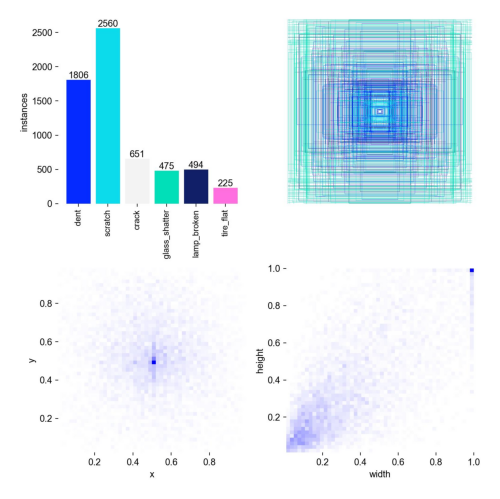

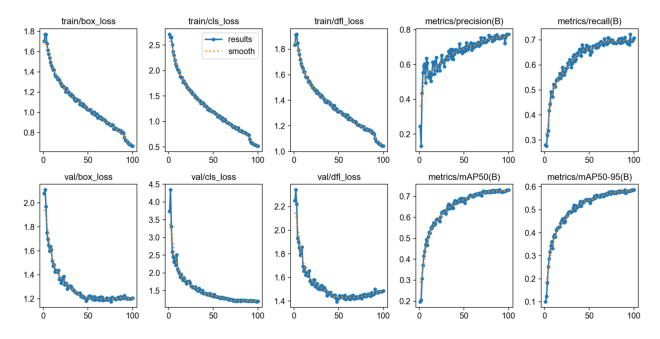

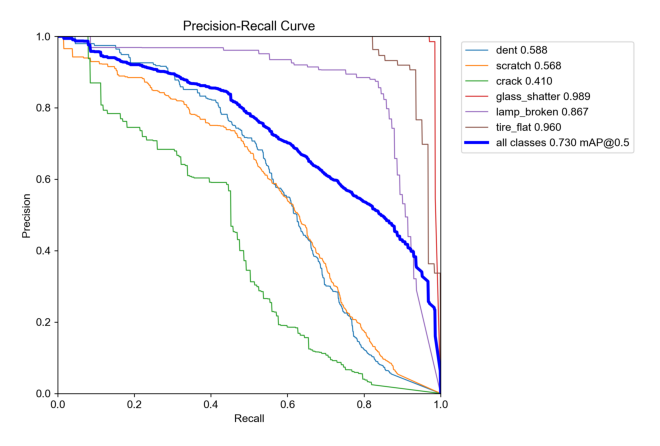

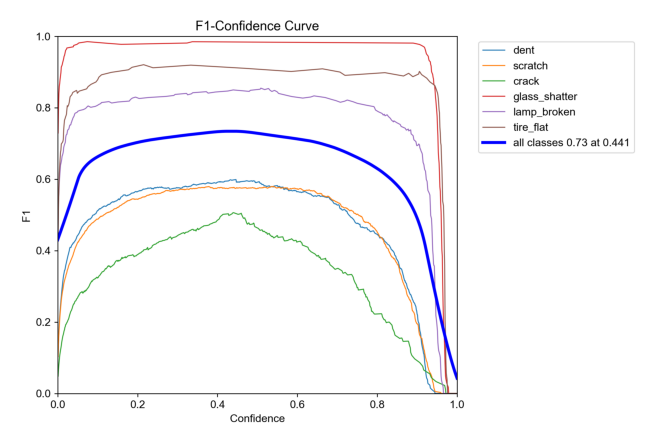

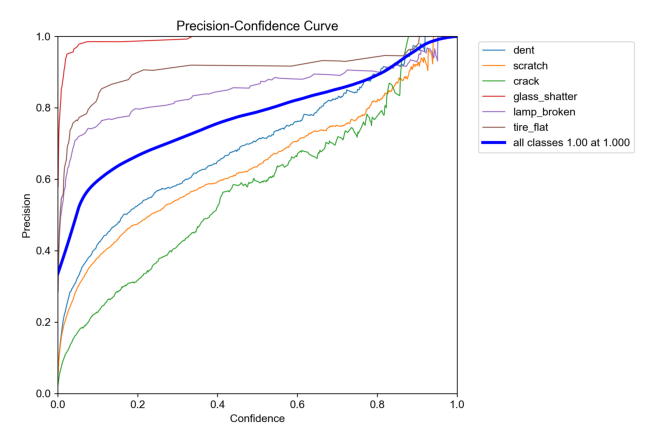

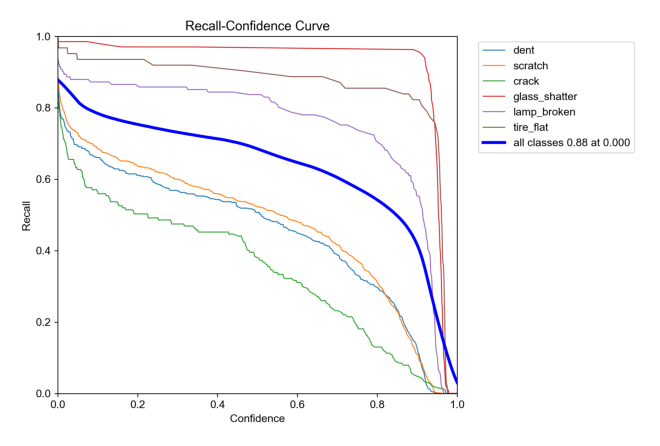

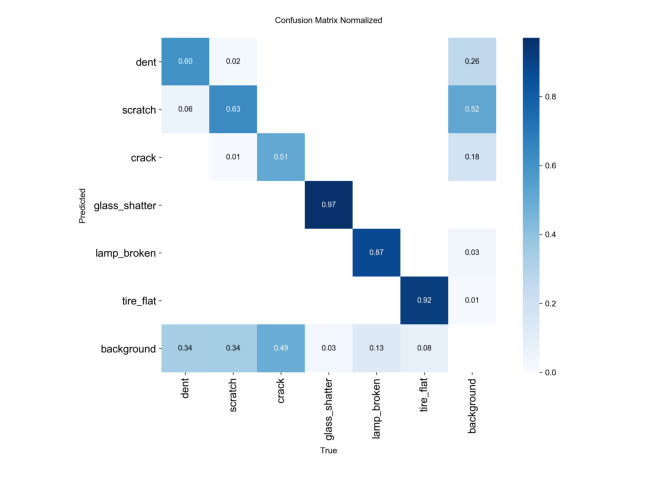

In [ ]:
print("="*60)
print("Training YOLO11m")
print("="*60)

purge_yolo_label_caches(yolo_yaml_path)

# Initialize YOLO11m model
yolo11m = load_ultralytics_model(YOLO, 'yolo11m.pt')  # Load pretrained weights

# Train the model
yolo11m_results = yolo11m.train(
    data=yolo_yaml_path,
    epochs=CONFIG['EPOCHS'],
    imgsz=CONFIG['IMAGE_SIZE'],
    batch=CONFIG['BATCH_SIZE'],
    device=ULTRA_DEVICE,
    workers=CONFIG['NUM_WORKERS'],
    project=CONFIG['OUTPUT_DIR'],
    name='yolo11m',
    exist_ok=True,
    pretrained=True,
    optimizer='AdamW',
    lr0=CONFIG['LEARNING_RATE'],
    weight_decay=CONFIG['WEIGHT_DECAY'],
    patience=20,  # Early stopping patience
    save=True,
    plots=True,
    verbose=True
)

# Store results
training_results['yolo11m'] = yolo11m_results
model_paths['yolo11m'] = os.path.join(CONFIG['OUTPUT_DIR'], 'yolo11m', 'weights', 'best.pt')

print("\n✓ YOLO11m training complete!")

### 3.2 YOLOv8m Training

In [ ]:
print("="*60)
print("Training YOLOv8m")
print("="*60)

purge_yolo_label_caches(yolo_yaml_path)

# Initialize YOLOv8m model
yolov8m = load_ultralytics_model(YOLO, 'yolov8m.pt')  # Load pretrained weights

# Train the model
yolov8m_results = yolov8m.train(
    data=yolo_yaml_path,
    epochs=CONFIG['EPOCHS'],
    imgsz=CONFIG['IMAGE_SIZE'],
    batch=CONFIG['BATCH_SIZE'],
    device=ULTRA_DEVICE,
    workers=CONFIG['NUM_WORKERS'],
    project=CONFIG['OUTPUT_DIR'],
    name='yolov8m',
    exist_ok=True,
    pretrained=True,
    optimizer='AdamW',
    lr0=CONFIG['LEARNING_RATE'],
    weight_decay=CONFIG['WEIGHT_DECAY'],
    patience=20,
    save=True,
    plots=True,
    verbose=True
)

# Store results
training_results['yolov8m'] = yolov8m_results
model_paths['yolov8m'] = os.path.join(CONFIG['OUTPUT_DIR'], 'yolov8m', 'weights', 'best.pt')

print("\n✓ YOLOv8m training complete!")

Training YOLOv8m
Removed cache: C:\Users\Bush\OneDrive\OneDrive - UTS\UTS Master\42028 Deep Learning and Convolutional Neural Network\Assignment 3\vehicle_damage_assessment\data\CarDD\CarDD_YOLO\labels\train.cache
Removed cache: C:\Users\Bush\OneDrive\OneDrive - UTS\UTS Master\42028 Deep Learning and Convolutional Neural Network\Assignment 3\vehicle_damage_assessment\data\CarDD\CarDD_YOLO\labels\val.cache
Removed 2 cache file(s).
New https://pypi.org/project/ultralytics/8.4.34 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.23  Python-3.13.4 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Bush\OneDrive\OneDrive - UTS\UTS Master\42028 Deep Learning and Convolutio

### 3.3 Faster R-CNN Training

In [ ]:
# Dataset for Faster R-CNN
class CarDDDataset(torch.utils.data.Dataset):
    """Dataset class for Faster R-CNN training"""
    
    def __init__(self, coco_obj, img_dir, transforms=None):
        self.coco = coco_obj
        self.img_dir = img_dir
        self.transforms = transforms
        self.img_ids = list(self.coco.imgs.keys())
    
    def __len__(self):
        return len(self.img_ids)
    
    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        
        # Load image
        img = Image.open(img_path).convert('RGB')
        
        # Get annotations
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        
        boxes = []
        labels = []
        areas = []
        iscrowd = []
        
        for ann in anns:
            bbox = ann['bbox']  # [x, y, width, height]
            # Convert to [x_min, y_min, x_max, y_max]
            x_min = bbox[0]
            y_min = bbox[1]
            x_max = bbox[0] + bbox[2]
            y_max = bbox[1] + bbox[3]
            
            # Skip invalid boxes
            if x_max <= x_min or y_max <= y_min:
                continue
            
            boxes.append([x_min, y_min, x_max, y_max])
            labels.append(ann['category_id'])  # Keep 1-indexed for torchvision
            areas.append(ann['area'])
            iscrowd.append(ann.get('iscrowd', 0))
        
        # Handle empty annotations
        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            areas = torch.as_tensor(areas, dtype=torch.float32)
            iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)
        
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([img_id]),
            'area': areas,
            'iscrowd': iscrowd
        }
        
        if self.transforms:
            img = self.transforms(img)
        else:
            img = transforms.ToTensor()(img)
        
        return img, target

def collate_fn(batch):
    """Custom collate function for variable-size targets"""
    return tuple(zip(*batch))

In [ ]:
def get_faster_rcnn_model(num_classes):
    """
    Get Faster R-CNN model with custom number of classes.
    Uses ResNet50 FPN V2 backbone with improved performance.
    """
    # Load pretrained model
    weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
    model = fasterrcnn_resnet50_fpn_v2(weights=weights)
    
    # Get number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    
    # Replace the head with a new one (num_classes + 1 for background)
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes + 1)
    
    return model

# Test model creation
test_model = get_faster_rcnn_model(CONFIG['NUM_CLASSES'])
print(f"Faster R-CNN model created with {CONFIG['NUM_CLASSES'] + 1} classes (including background)")

In [ ]:
# Fix SSL certificate issue for downloading pretrained weights (macOS)
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
print("✓ SSL fix applied - you can now download pretrained models")

In [ ]:
print("="*60)
print("Training Faster R-CNN")
print("="*60)

# Create datasets
train_transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = CarDDDataset(
    train_coco, 
    data_root / CONFIG['TRAIN_IMAGES'],
    transforms=train_transform
)

val_dataset = CarDDDataset(
    val_coco,
    data_root / CONFIG['VAL_IMAGES'],
    transforms=train_transform
)

# Create data loaders
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=2,  # Reduced batch size for Faster R-CNN
    shuffle=True,
    num_workers=CONFIG['NUM_WORKERS'],
    collate_fn=collate_fn,
    pin_memory=True if SAFE_DEVICE_TYPE == 'cuda' else False
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=2,  # Reduced batch size
    shuffle=False,
    num_workers=CONFIG['NUM_WORKERS'],
    collate_fn=collate_fn,
    pin_memory=True if SAFE_DEVICE_TYPE == 'cuda' else False
)

print(f"Train dataset: {len(train_dataset)} images")
print(f"Val dataset: {len(val_dataset)} images")
print(f"Faster R-CNN device: {SAFE_TORCH_DEVICE}")

In [ ]:
def train_faster_rcnn(model, train_loader, val_loader, num_epochs, device, output_dir):
    """
    Train Faster R-CNN model with validation.
    """
    model = model.to(device)
    
    # Optimizer
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(
        params,
        lr=CONFIG['LEARNING_RATE'],
        weight_decay=CONFIG['WEIGHT_DECAY']
    )
    
    # Learning rate scheduler
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, 
        T_max=num_epochs,
        eta_min=CONFIG['LEARNING_RATE'] * 0.01
    )
    
    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'learning_rate': []
    }
    
    best_loss = float('inf')
    patience_counter = 0
    patience = 20
    
    os.makedirs(output_dir, exist_ok=True)
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
        for images, targets in pbar:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            # Forward pass
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            
            # Backward pass
            optimizer.zero_grad()
            losses.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(params, max_norm=10.0)
            
            optimizer.step()
            
            train_loss += losses.item()
            pbar.set_postfix({'loss': f'{losses.item():.4f}'})
        
        train_loss /= len(train_loader)
        
        # Validation phase
        model.train()  # Keep in train mode for loss computation
        val_loss = 0.0
        
        with torch.no_grad():
            for images, targets in tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]'):
                images = [img.to(device) for img in images]
                targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
                
                loss_dict = model(images, targets)
                losses = sum(loss for loss in loss_dict.values())
                val_loss += losses.item()
        
        val_loss /= len(val_loader)
        
        # Update learning rate
        lr_scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        
        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['learning_rate'].append(current_lr)
        
        # Log to ClearML
        clearml_logger.report_scalar("Faster R-CNN", "Train Loss", train_loss, epoch)
        clearml_logger.report_scalar("Faster R-CNN", "Val Loss", val_loss, epoch)
        clearml_logger.report_scalar("Faster R-CNN", "Learning Rate", current_lr, epoch)
        
        print(f'Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.6f}')
        
        # Save best model
        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'train_loss': train_loss,
            }, os.path.join(output_dir, 'best.pt'))
            print(f'  -> New best model saved! Val Loss: {val_loss:.4f}')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping triggered after {epoch+1} epochs')
                break
        
        # Save last model
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'train_loss': train_loss,
        }, os.path.join(output_dir, 'last.pt'))
    
    return model, history

In [ ]:
# Train Faster R-CNN
faster_rcnn_model = get_faster_rcnn_model(CONFIG['NUM_CLASSES'])
faster_rcnn_output_dir = os.path.join(CONFIG['OUTPUT_DIR'], 'faster_rcnn')

faster_rcnn_model, faster_rcnn_history = train_faster_rcnn(
    faster_rcnn_model,
    train_loader,
    val_loader,
    CONFIG['EPOCHS'],
    SAFE_TORCH_DEVICE,
    faster_rcnn_output_dir
)

training_results['faster_rcnn'] = faster_rcnn_history
model_paths['faster_rcnn'] = os.path.join(faster_rcnn_output_dir, 'best.pt')

print("\n✓ Faster R-CNN training complete!")

### 3.4 RT-DETR Training

In [ ]:
print("="*60)
print("Training RT-DETR")
print("="*60)

purge_yolo_label_caches(yolo_yaml_path)

# Initialize RT-DETR model (using Ultralytics implementation)
rtdetr = load_ultralytics_model(RTDETR, 'rtdetr-l.pt')  # Load pretrained RT-DETR-L

# Train the model
rtdetr_results = rtdetr.train(
    data=yolo_yaml_path,
    epochs=CONFIG['EPOCHS'],
    imgsz=CONFIG['IMAGE_SIZE'],
    batch=2,  # Reduced batch size for RT-DETR
    device=ULTRA_DEVICE,
    workers=CONFIG['NUM_WORKERS'],
    project=CONFIG['OUTPUT_DIR'],
    name='rtdetr',
    exist_ok=True,
    optimizer='AdamW',
    lr0=CONFIG['LEARNING_RATE'] * 0.1,  # Lower LR for transformer
    weight_decay=CONFIG['WEIGHT_DECAY'],
    patience=20,
    save=True,
    plots=True,
    verbose=True
)

# Store results
training_results['rtdetr'] = rtdetr_results
model_paths['rtdetr'] = os.path.join(CONFIG['OUTPUT_DIR'], 'rtdetr', 'weights', 'best.pt')

print("\n✓ RT-DETR training complete!")

---
## 4. Model Evaluation and Comparison

In [ ]:
def evaluate_yolo_model(model_path, data_yaml, device, model_name):
    """
    Evaluate a YOLO-family model and return metrics.
    """
    print(f"\nEvaluating {model_name}...")
    
    # Load model
    if 'rtdetr' in model_name.lower():
        model = RTDETR(model_path)
    else:
        model = YOLO(model_path)
    
    # Run validation
    results = model.val(
        data=data_yaml,
        device=device,
        split='test',
        conf=CONFIG['CONF_THRESHOLD'],
        iou=CONFIG['IOU_THRESHOLD'],
        verbose=False
    )
    
    # Measure inference time
    inference_times = []
    test_images_dir = os.path.join(yolo_data_dir, 'images', 'test')
    test_images = os.listdir(test_images_dir)[:50]  # Sample 50 images
    
    for img_name in test_images:
        img_path = os.path.join(test_images_dir, img_name)
        
        start_time = time.time()
        _ = model.predict(img_path, verbose=False, device=device)
        inference_times.append((time.time() - start_time) * 1000)  # Convert to ms
    
    avg_inference_time = np.mean(inference_times)
    
    metrics = {
        'model': model_name,
        'mAP50': results.box.map50,
        'mAP50-95': results.box.map,
        'precision': results.box.mp,
        'recall': results.box.mr,
        'inference_time_ms': avg_inference_time
    }
    
    # Per-class metrics
    class_metrics = {}
    for i, class_name in enumerate(CONFIG['CLASS_NAMES']):
        if i < len(results.box.ap50):
            class_metrics[class_name] = {
                'ap50': results.box.ap50[i],
                'ap': results.box.ap[i]
            }
    
    metrics['per_class'] = class_metrics
    
    return metrics, model

In [ ]:
def evaluate_faster_rcnn(model_path, test_dataset, device):
    """
    Evaluate Faster R-CNN model using COCO evaluation metrics.
    """
    print("\nEvaluating Faster R-CNN...")
    
    # Load model
    model = get_faster_rcnn_model(CONFIG['NUM_CLASSES'])
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(device)
    model.eval()
    
    # Test data loader
    test_loader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn
    )
    
    # Collect predictions
    all_predictions = []
    all_targets = []
    inference_times = []
    
    with torch.no_grad():
        for images, targets in tqdm(test_loader, desc='Evaluating'):
            images = [img.to(device) for img in images]
            
            start_time = time.time()
            outputs = model(images)
            inference_times.append((time.time() - start_time) * 1000)
            
            for output, target in zip(outputs, targets):
                all_predictions.append(output)
                all_targets.append(target)
    
    # Calculate metrics
    avg_inference_time = np.mean(inference_times)
    
    # Simple mAP calculation
    def calculate_ap(predictions, targets, iou_threshold=0.5):
        """Calculate Average Precision for one class"""
        all_scores = []
        all_matches = []
        
        for pred, target in zip(predictions, targets):
            pred_boxes = pred['boxes'].cpu().numpy()
            pred_scores = pred['scores'].cpu().numpy()
            pred_labels = pred['labels'].cpu().numpy()
            
            gt_boxes = target['boxes'].cpu().numpy()
            gt_labels = target['labels'].cpu().numpy()
            
            # Filter by confidence
            conf_mask = pred_scores >= CONFIG['CONF_THRESHOLD']
            pred_boxes = pred_boxes[conf_mask]
            pred_scores = pred_scores[conf_mask]
            pred_labels = pred_labels[conf_mask]
            
            matched_gt = set()
            for i, (box, score, label) in enumerate(zip(pred_boxes, pred_scores, pred_labels)):
                all_scores.append(score)
                
                # Find matching ground truth
                best_iou = 0
                best_gt_idx = -1
                
                for j, (gt_box, gt_label) in enumerate(zip(gt_boxes, gt_labels)):
                    if j in matched_gt or gt_label != label:
                        continue
                    
                    # Calculate IoU
                    x1 = max(box[0], gt_box[0])
                    y1 = max(box[1], gt_box[1])
                    x2 = min(box[2], gt_box[2])
                    y2 = min(box[3], gt_box[3])
                    
                    inter = max(0, x2 - x1) * max(0, y2 - y1)
                    area1 = (box[2] - box[0]) * (box[3] - box[1])
                    area2 = (gt_box[2] - gt_box[0]) * (gt_box[3] - gt_box[1])
                    union = area1 + area2 - inter
                    
                    iou = inter / union if union > 0 else 0
                    
                    if iou > best_iou:
                        best_iou = iou
                        best_gt_idx = j
                
                if best_iou >= iou_threshold:
                    matched_gt.add(best_gt_idx)
                    all_matches.append(1)
                else:
                    all_matches.append(0)
        
        if len(all_scores) == 0:
            return 0.0
        
        # Sort by scores
        sorted_indices = np.argsort(all_scores)[::-1]
        all_matches = np.array(all_matches)[sorted_indices]
        
        # Calculate precision and recall
        tp = np.cumsum(all_matches)
        fp = np.cumsum(1 - all_matches)
        
        total_gt = sum(len(t['boxes']) for t in targets)
        
        precision = tp / (tp + fp)
        recall = tp / total_gt if total_gt > 0 else np.zeros_like(tp)
        
        # Calculate AP using 101-point interpolation
        ap = 0
        for t in np.arange(0, 1.01, 0.01):
            prec_at_recall = precision[recall >= t]
            if len(prec_at_recall) > 0:
                ap += np.max(prec_at_recall)
        ap /= 101
        
        return ap
    
    # Calculate mAP@0.5
    mAP50 = calculate_ap(all_predictions, all_targets, iou_threshold=0.5)
    
    # Calculate mAP@0.5:0.95
    aps = []
    for iou_thresh in np.arange(0.5, 1.0, 0.05):
        aps.append(calculate_ap(all_predictions, all_targets, iou_threshold=iou_thresh))
    mAP50_95 = np.mean(aps)
    
    # Calculate precision and recall
    total_tp = 0
    total_fp = 0
    total_fn = 0
    
    for pred, target in zip(all_predictions, all_targets):
        pred_boxes = pred['boxes'].cpu().numpy()
        pred_scores = pred['scores'].cpu().numpy()
        gt_boxes = target['boxes'].cpu().numpy()
        
        conf_mask = pred_scores >= CONFIG['CONF_THRESHOLD']
        pred_boxes = pred_boxes[conf_mask]
        
        matched = 0
        for box in pred_boxes:
            for gt_box in gt_boxes:
                x1 = max(box[0], gt_box[0])
                y1 = max(box[1], gt_box[1])
                x2 = min(box[2], gt_box[2])
                y2 = min(box[3], gt_box[3])
                
                inter = max(0, x2 - x1) * max(0, y2 - y1)
                area1 = (box[2] - box[0]) * (box[3] - box[1])
                area2 = (gt_box[2] - gt_box[0]) * (gt_box[3] - gt_box[1])
                union = area1 + area2 - inter
                
                if inter / union >= 0.5:
                    matched += 1
                    break
        
        total_tp += matched
        total_fp += len(pred_boxes) - matched
        total_fn += len(gt_boxes) - matched
    
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    
    metrics = {
        'model': 'Faster R-CNN',
        'mAP50': mAP50,
        'mAP50-95': mAP50_95,
        'precision': precision,
        'recall': recall,
        'inference_time_ms': avg_inference_time
    }
    
    return metrics, model

In [ ]:
# Evaluate all models
print("="*60)
print("Evaluating All Models on Test Set")
print("="*60)

purge_yolo_label_caches(yolo_yaml_path)

evaluation_results = {}
loaded_models = {}

# Evaluate YOLO11m
if os.path.exists(model_paths.get('yolo11m', '')):
    metrics, model = evaluate_yolo_model(
        model_paths['yolo11m'], 
        yolo_yaml_path, 
        SAFE_DEVICE_TYPE,
        'YOLO11m'
    )
    evaluation_results['yolo11m'] = metrics
    loaded_models['yolo11m'] = model

# Evaluate YOLOv8m
if os.path.exists(model_paths.get('yolov8m', '')):
    metrics, model = evaluate_yolo_model(
        model_paths['yolov8m'], 
        yolo_yaml_path, 
        SAFE_DEVICE_TYPE,
        'YOLOv8m'
    )
    evaluation_results['yolov8m'] = metrics
    loaded_models['yolov8m'] = model

# Evaluate Faster R-CNN
if os.path.exists(model_paths.get('faster_rcnn', '')):
    test_dataset = CarDDDataset(
        test_coco,
        data_root / CONFIG['TEST_IMAGES'],
        transforms=transforms.Compose([transforms.ToTensor()])
    )
    metrics, model = evaluate_faster_rcnn(
        model_paths['faster_rcnn'],
        test_dataset,
        SAFE_TORCH_DEVICE
    )
    evaluation_results['faster_rcnn'] = metrics
    loaded_models['faster_rcnn'] = model

# Evaluate RT-DETR
if os.path.exists(model_paths.get('rtdetr', '')):
    metrics, model = evaluate_yolo_model(
        model_paths['rtdetr'], 
        yolo_yaml_path, 
        SAFE_DEVICE_TYPE,
        'RT-DETR'
    )
    evaluation_results['rtdetr'] = metrics
    loaded_models['rtdetr'] = model

print("\n✓ All model evaluations complete!")

### 4.1 Results Comparison

In [ ]:
# Create comparison table
comparison_data = []

for model_name, metrics in evaluation_results.items():
    comparison_data.append({
        'Model': metrics['model'],
        'mAP@0.5': f"{metrics['mAP50']:.4f}",
        'mAP@0.5:0.95': f"{metrics['mAP50-95']:.4f}",
        'Precision': f"{metrics['precision']:.4f}",
        'Recall': f"{metrics['recall']:.4f}",
        'Inference (ms)': f"{metrics['inference_time_ms']:.2f}"
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("MODEL COMPARISON RESULTS")
print("="*80)
print(tabulate(comparison_df, headers='keys', tablefmt='grid', showindex=False))

# Log to ClearML
clearml_logger.report_table("Model Comparison", "Test Set Results", table_plot=comparison_df)

# Save to CSV
comparison_df.to_csv(f"{CONFIG['OUTPUT_DIR']}/model_comparison.csv", index=False)
print(f"\nResults saved to: {CONFIG['OUTPUT_DIR']}/model_comparison.csv")

In [ ]:
# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = [m['model'] for m in comparison_data]
map50 = [float(m['mAP@0.5']) for m in comparison_data]
map50_95 = [float(m['mAP@0.5:0.95']) for m in comparison_data]
precision = [float(m['Precision']) for m in comparison_data]
recall = [float(m['Recall']) for m in comparison_data]
inference = [float(m['Inference (ms)']) for m in comparison_data]

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(models)))

# mAP comparison
x = np.arange(len(models))
width = 0.35
axes[0, 0].bar(x - width/2, map50, width, label='mAP@0.5', color='steelblue')
axes[0, 0].bar(x + width/2, map50_95, width, label='mAP@0.5:0.95', color='darkorange')
axes[0, 0].set_ylabel('mAP')
axes[0, 0].set_title('Mean Average Precision')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models, rotation=15)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Precision & Recall
axes[0, 1].bar(x - width/2, precision, width, label='Precision', color='forestgreen')
axes[0, 1].bar(x + width/2, recall, width, label='Recall', color='crimson')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_title('Precision & Recall')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models, rotation=15)
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# Inference time
axes[1, 0].bar(models, inference, color=colors)
axes[1, 0].set_ylabel('Time (ms)')
axes[1, 0].set_title('Inference Time per Image')
axes[1, 0].tick_params(axis='x', rotation=15)
axes[1, 0].grid(axis='y', alpha=0.3)

# Efficiency plot (mAP vs Speed)
for i, model in enumerate(models):
    axes[1, 1].scatter(inference[i], map50[i], s=200, c=[colors[i]], label=model, edgecolors='black')
axes[1, 1].set_xlabel('Inference Time (ms)')
axes[1, 1].set_ylabel('mAP@0.5')
axes[1, 1].set_title('Accuracy vs Speed Trade-off')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CONFIG['OUTPUT_DIR']}/model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

clearml_logger.report_matplotlib_figure("Comparison", "Model Metrics", fig)

### 4.2 Per-Class Performance Analysis

In [ ]:
# Per-class AP comparison (for YOLO models)
per_class_data = []

for model_name, metrics in evaluation_results.items():
    if 'per_class' in metrics:
        for class_name, class_metrics in metrics['per_class'].items():
            per_class_data.append({
                'Model': metrics['model'],
                'Class': class_name,
                'AP@0.5': class_metrics.get('ap50', 0),
                'AP@0.5:0.95': class_metrics.get('ap', 0)
            })

if per_class_data:
    per_class_df = pd.DataFrame(per_class_data)
    
    # Pivot for visualization
    pivot_df = per_class_df.pivot(index='Class', columns='Model', values='AP@0.5')
    
    fig, ax = plt.subplots(figsize=(12, 6))
    pivot_df.plot(kind='bar', ax=ax, width=0.8)
    ax.set_ylabel('AP@0.5')
    ax.set_title('Per-Class Average Precision Comparison')
    ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f"{CONFIG['OUTPUT_DIR']}/per_class_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    clearml_logger.report_matplotlib_figure("Comparison", "Per-Class AP", fig)

### 4.3 Select Best Model

In [ ]:
# Determine the best model based on mAP@0.5
best_model_name = None
best_map50 = 0

for model_name, metrics in evaluation_results.items():
    if metrics['mAP50'] > best_map50:
        best_map50 = metrics['mAP50']
        best_model_name = model_name

print("="*60)
print("BEST MODEL SELECTION")
print("="*60)
print(f"\nBest Model: {evaluation_results[best_model_name]['model']}")
print(f"   mAP@0.5: {best_map50:.4f}")
print(f"   mAP@0.5:0.95: {evaluation_results[best_model_name]['mAP50-95']:.4f}")
print(f"   Inference Time: {evaluation_results[best_model_name]['inference_time_ms']:.2f} ms")

# Copy best model to deployment location
best_model_src = model_paths[best_model_name]
best_model_dst = os.path.join(CONFIG['OUTPUT_DIR'], 'best_model.pt')

if os.path.exists(best_model_src):
    shutil.copy2(best_model_src, best_model_dst)
    print(f"\n✓ Best model saved to: {best_model_dst}")

# Log to ClearML
task.set_parameter('best_model', best_model_name)
task.set_parameter('best_mAP50', best_map50)

---
## 5. Inference Demonstration

In [ ]:
def visualize_predictions(model, image_path, model_name, conf_threshold=0.25):
    """
    Visualize model predictions on a single image.
    """
    # Load and predict
    if isinstance(model, (YOLO, RTDETR)):
        results = model.predict(image_path, conf=conf_threshold, verbose=False, device=SAFE_DEVICE_TYPE)
        
        # Get annotated image
        annotated = results[0].plot()
        annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        
        detections = results[0].boxes
        
    else:  # Faster R-CNN
        img = Image.open(image_path).convert('RGB')
        img_tensor = transforms.ToTensor()(img).unsqueeze(0).to(SAFE_TORCH_DEVICE)
        
        model.eval()
        with torch.no_grad():
            predictions = model(img_tensor)[0]
        
        # Draw predictions
        annotated = np.array(img)
        
        for i, (box, score, label) in enumerate(zip(
            predictions['boxes'].cpu().numpy(),
            predictions['scores'].cpu().numpy(),
            predictions['labels'].cpu().numpy()
        )):
            if score >= conf_threshold:
                x1, y1, x2, y2 = box.astype(int)
                class_name = CONFIG['CLASS_NAMES'][label - 1]
                
                cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(
                    annotated, f'{class_name}: {score:.2f}',
                    (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (0, 255, 0), 2
                )
        
        detections = predictions
    
    return annotated, detections

# Visualize predictions from best model on sample test images
test_images_dir = data_root / CONFIG['TEST_IMAGES']
sample_images = list(test_images_dir.glob('*.jpg'))[:6]

if best_model_name and loaded_models.get(best_model_name):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, img_path in enumerate(sample_images):
        annotated, _ = visualize_predictions(
            loaded_models[best_model_name],
            str(img_path),
            best_model_name
        )
        axes[idx].imshow(annotated)
        axes[idx].set_title(f'{img_path.name}')
        axes[idx].axis('off')
    
    plt.suptitle(f'Predictions by {evaluation_results[best_model_name]["model"]} (Best Model)', fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['OUTPUT_DIR']}/sample_predictions.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    clearml_logger.report_matplotlib_figure("Inference", "Sample Predictions", fig)

---
## 6. Model Export for Deployment

In [ ]:
# Export best model in various formats for deployment
export_dir = os.path.join(CONFIG['OUTPUT_DIR'], 'exports')
os.makedirs(export_dir, exist_ok=True)

if best_model_name in ['yolo11m', 'yolov8m', 'rtdetr']:
    best_model = loaded_models[best_model_name]
    
    print("Exporting model formats...")
    
    # Export to ONNX (for cross-platform deployment)
    try:
        onnx_path = best_model.export(format='onnx', simplify=True)
        print(f"  ✓ ONNX: {onnx_path}")
    except Exception as e:
        print(f"  ✗ ONNX export failed: {e}")
    
    # Export to TorchScript (for PyTorch mobile)
    try:
        torchscript_path = best_model.export(format='torchscript')
        print(f"  ✓ TorchScript: {torchscript_path}")
    except Exception as e:
        print(f"  ✗ TorchScript export failed: {e}")
    
    print("\n✓ Model export complete!")
else:
    print("Faster R-CNN model - manual export required")
    print(f"Model saved at: {model_paths['faster_rcnn']}")

---
## 7. Summary and Recommendations

In [ ]:
print("="*80)
print("EXPERIMENT SUMMARY")
print("="*80)

print("\nDataset Statistics:")
print(f"   - Training images: {len(train_coco.imgs)}")
print(f"   - Validation images: {len(val_coco.imgs)}")
print(f"   - Test images: {len(test_coco.imgs)}")
print(f"   - Classes: {CONFIG['NUM_CLASSES']} damage types")

print("\nModels Trained:")
for model_name, metrics in evaluation_results.items():
    print(f"   - {metrics['model']}: mAP@0.5 = {metrics['mAP50']:.4f}")

print(f"\nBest Model: {evaluation_results[best_model_name]['model']}")
print(f"   - mAP@0.5: {evaluation_results[best_model_name]['mAP50']:.4f}")
print(f"   - mAP@0.5:0.95: {evaluation_results[best_model_name]['mAP50-95']:.4f}")
print(f"   - Inference: {evaluation_results[best_model_name]['inference_time_ms']:.2f} ms")

print("\nRecommendations:")
print(f"   1. Deploy {evaluation_results[best_model_name]['model']} as the production model")
print("   2. Use ONNX format for cross-platform compatibility")
print("   3. Consider model quantization for mobile deployment")
print("   4. Implement confidence threshold tuning for production")

print("\nOutputs:")
print(f"   - Models: {CONFIG['OUTPUT_DIR']}/")
print(f"   - Best model: {CONFIG['OUTPUT_DIR']}/best_model.pt")
print(f"   - Comparison CSV: {CONFIG['OUTPUT_DIR']}/model_comparison.csv")
print(f"   - ClearML Dashboard: https://app.clear.ml")

# Close ClearML task
task.close()
print("\n✓ ClearML task completed and closed.")

In [ ]:
# Save final configuration for backend deployment
deployment_config = {
    'model': {
        'name': evaluation_results[best_model_name]['model'],
        'path': '../models/best_model.pt',
        'type': best_model_name,
        'metrics': {
            'mAP50': float(evaluation_results[best_model_name]['mAP50']),
            'mAP50_95': float(evaluation_results[best_model_name]['mAP50-95']),
            'inference_time_ms': float(evaluation_results[best_model_name]['inference_time_ms'])
        }
    },
    'inference': {
        'image_size': CONFIG['IMAGE_SIZE'],
        'conf_threshold': CONFIG['CONF_THRESHOLD'],
        'iou_threshold': CONFIG['IOU_THRESHOLD'],
        'classes': CONFIG['CLASS_NAMES']
    },
    'training': {
        'epochs': CONFIG['EPOCHS'],
        'batch_size': CONFIG['BATCH_SIZE'],
        'device': SAFE_DEVICE_TYPE
    }
}

with open(f"{CONFIG['OUTPUT_DIR']}/deployment_config.yaml", 'w') as f:
    yaml.dump(deployment_config, f, default_flow_style=False)

print(f"Deployment configuration saved to: {CONFIG['OUTPUT_DIR']}/deployment_config.yaml")